In [1]:
import copy
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.animation import FuncAnimation
from collections import defaultdict
from water_sim_basic import WaterSim

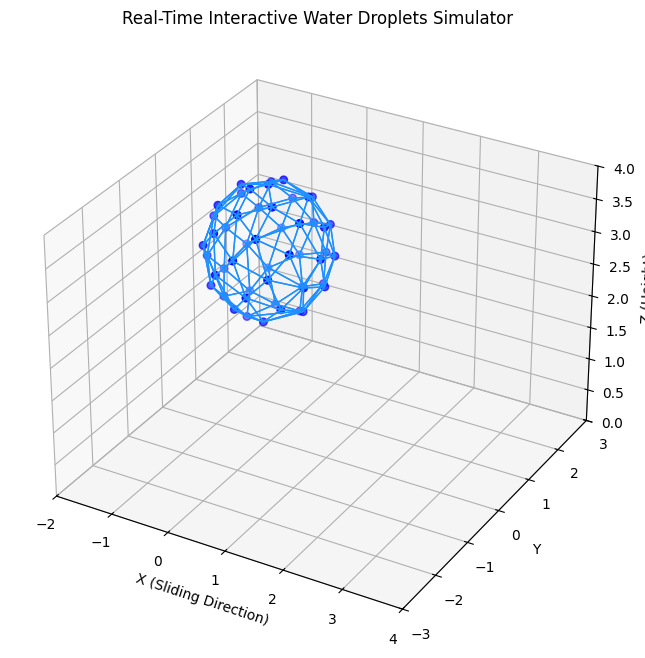

In [ ]:
def init_sim():
    x, faces, neighbours = WaterSim.generate_polyhedron(n_vertices=50, radius=1.0)
    # x, faces, neighbours = WaterSim.generate_rectangular_cube_mesh(length=2.0)
    
    v = np.zeros_like(x)
    x += np.array([0, 0, 3.0]) # Drop height
    
    sim = WaterSim(
        x, 
        v, 
        faces, 
        neighbours, 
        g=np.array([0.0, 0.0, -9.81]), 
        gamma=50.0, 
        mu=.0, 
        eta=0.1, 
        k_v=2000.0, 
        # rho=0.10, 
        boundary_alpha=0.15, 
        friction_coeff=0.2, 
        density=1.0,
        # contact_angles=(np.deg2rad(85.0), np.deg2rad(95.0)), 
    )
    
    return x, v, neighbours, faces, sim.V_0, sim

x, v, neighbours, faces, V_0, sim = init_sim()

# Simulation Settings
dt = 0.008
sub_steps = 8
sub_dt = dt / sub_steps

# Rendering Setup
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

def get_edge_segments(x, faces):
    return x[faces[:, [0, 1, 1, 2, 2, 0]]].reshape(-1, 2, 3)

lines = Line3DCollection(get_edge_segments(x, faces), colors="dodgerblue", linewidths=1.0)
ax.add_collection3d(lines)
sc = ax.scatter(x[:, 0], x[:, 1], x[:, 2], c="blue", s=30)

ax.set(xlim=(-2, 4), ylim=(-3, 3), zlim=(0, 4), 
       xlabel="X (Sliding Direction)", ylabel="Y", zlabel="Z (Height)",
       title="Real-Time Interactive Water Droplets Simulator")

def update_anim(frame):
    """
    Geometry:
    - n_vertices (Resolution): Higher = smoother deformations but requires smaller dt for stability; Lower = blocky but fast.

    Forces & Dynamics:
    - gamma (Surface Tension): Higher = stiffer, spherical droplet; Lower = flattens into a loose puddle.
    - mu (Global Damping): Overall viscosity. Higher = loses momentum quickly (thick fluid); Lower = bouncy/elastic.
    - eta (Laplacian Viscosity): Surface damping. Higher = smooth, unified surface movement; Lower = allows localized ripples/waves.
    - k_v (Volume Stiffness): Incompressibility constraint. Higher = fiercely resists volume change; Lower = slowly deflates.
    - friction_coeff (Friction): Surface adhesion. Higher = sticky, resists sliding; Lower = slippery, slides easily.
    """

    global x, v
    
    v, x = sim.step_simulation(dt, method="euler", volume_correction_mode="both")
        
    sc._offsets3d = (x[:, 0], x[:, 1], x[:, 2])
    lines.set_segments(get_edge_segments(x, faces))
    return sc, lines

In [ ]:
ani = FuncAnimation(fig, update_anim, frames=500, interval=1, blit=True)

try:
    from IPython.display import display, HTML
    import matplotlib
    matplotlib.rcParams['animation.embed_limit'] = 600.0
    display(HTML(ani.to_jshtml()))
    plt.close()
except ImportError:
    plt.show()